In [44]:
import os

from langgraph.graph import StateGraph, START,END
from langchain_groq import ChatGroq
from typing import Literal,TypedDict
from pydantic import BaseModel,Field
from dotenv import load_dotenv

load_dotenv()

True

In [45]:
llm = ChatGroq(model=os.getenv('GROQ_MODEL'), api_key=os.getenv('GROQ_API_KEY'))

In [46]:
class PostState(TypedDict):

    topic: str
    post:str
    evaluation: Literal['approved','needs_improvement']
    feedback :str
    iteration: int
    max_iterations: int

In [47]:
class EvaluatePostSchema(BaseModel):

    evaluation: Literal['approved','needs_improvement'] = Field(description="LinkedIn post evaluation result post review")
    feedback: str = Field(description="Constructive feedback for the LinkedIn Post")

In [48]:
llm_evaluator = llm.with_structured_output(EvaluatePostSchema)

In [49]:
def generate_post(state:PostState):

    prompt = f"""Generate a professional LinkedIn post on the topic {state['topic']} based on the following criteria.
    
    1. Limit to maximum 200 words.
    2. Post should be thought provoking and has potential to go viral.
    3. Cite references if any facts used.
    """

    post = llm.invoke(prompt).content

    return {"post":post}

In [50]:
def evaluate_post(state:PostState):

    prompt = f""" You are a strict LinkenIn Post critic/reviewer. You need to evaluate the LinkedIn Post {state['post']} and provide evaluation result and detailed feedback.
    At minimum below criteria should be met for mvp
    1. Limit to maximum 200 words.
    2. Post should be thought provoking and has potential to go viral.
    3. Cite references if any facts used.
    """

    response = llm_evaluator.invoke(prompt)

    return {"evaluation":response.evaluation,"feedback": response.feedback}


In [51]:
def optimize_post(state:PostState):

    prompt= f""" You are a LinkedIn Post optimizer agent who needs to improve the LinkedIn Post {state['post']} based on the following feedback {state['feedback']}
    At minimum below criteria should be met for mvp
    1. Limit to maximum 200 words.
    2. Post should be thought provoking and has potential to go viral.
    3. Cite references if any facts used.
    """

    post = llm.invoke(prompt).content
    state['iteration'] += 1
    return {"post":post}

In [52]:
def routing_fn(state: PostState) -> Literal['approved','needs_improvement']:
    if state['evaluation'] == 'approved':
        return 'approved'
    elif state['iteration'] < state['max_iterations']:
        return 'needs_improvement'
    else:
        return 'approved'  # force-stop after max_iterations

In [53]:
graph = StateGraph(PostState)

graph.add_node('generate_post',generate_post)
graph.add_node('evaluate_post',evaluate_post)
graph.add_node('optimize_post',optimize_post)

graph.add_edge(START,'generate_post')
graph.add_edge('generate_post','evaluate_post')
graph.add_conditional_edges('evaluate_post',routing_fn,{'approved': END, 'needs_improvement': 'optimize_post'})
graph.add_edge('optimize_post','evaluate_post')

workflow = graph.compile()

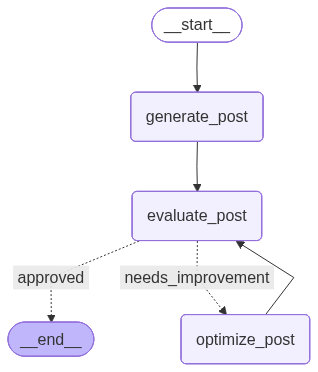

In [54]:
workflow

In [57]:
initial_state = {"topic": "Retrieval Augmented Generation in Healthcare",
                 "iteration" : 0,
                 "max_iterations": 5
                 }

final_state = workflow.invoke(initial_state)

In [58]:
final_state

{'topic': 'Retrieval Augmented Generation in Healthcare',
 'post': '"Revolutionizing Healthcare: The Power of Retrieval Augmented Generation\n\nImagine a future where healthcare professionals can generate personalized treatment plans, medical reports, and patient summaries with unprecedented accuracy and speed. Retrieval Augmented Generation (RAG) is making this a reality.\n\nBy combining the strengths of retrieval-based and generation-based approaches, RAG enables the creation of high-quality, context-specific content (1). In healthcare, this means improved patient outcomes, reduced clinician burnout, and enhanced decision-making (2).\n\nAs noted by researchers, RAG has the potential to "transform the way we interact with medical information" (3). I\'d love to hear from you - how do you think RAG will impact the future of healthcare?\n\nReferences:\n(1) Lewis et al. (2020) - Retrieval-Augmented Generation for Medical Question Answering\n(2) AMA Journal of Ethics (2020) - The Future of